# Train the Tiny MAE-ViT on ImageNet

Train the root-level `mae.py` model on a small streamed subset of `benjamin-paine/imagenet-1k-128x128`. This is a smoke experiment: success means held-out masked reconstruction loss drops and reconstructed patches become more plausible.

In [1]:
from __future__ import annotations

import math
import random
from itertools import islice

import matplotlib.pyplot as plt
import torch
from datasets import load_dataset
from tqdm.auto import tqdm
from torchvision.transforms import v2

from mae import (
    MaeConfig,
    MaskedAutoencoderViT,
    make_patch_mask,
    masked_reconstruction_loss,
    patchify,
    unpatchify,
)

SEED = 7
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

c:\Users\luequ\micromamba\envs\torch311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device(type='cuda')

## Experiment setup

- Stream ImageNet instead of downloading the full multi-gigabyte dataset.
- Stream the entire shuffled training split exactly once, materializing only the current batch.
- Resize images from `128x128` to `64x64` for recognizable outputs without making the laptop run unwieldy.
- Train with masks derived from `(image_id, step, seed)`.
- Compare validation reconstruction loss before and after training on one fixed mask.

In [2]:
config = MaeConfig(
    image_size=64,
    patch_size=8,
    encoder_dim=192,
    encoder_depth=4,
    encoder_heads=6,
    decoder_dim=128,
    decoder_depth=2,
    decoder_heads=4,
    mlp_ratio=4.0,
    mask_ratio=0.50,
)
num_eval_images = 128
batch_size = 128
learning_rate = 1e-3
shuffle_buffer_size = 10_000

image_transform = v2.Compose(
    [
        v2.ToImage(),
        v2.Resize((config.image_size, config.image_size), antialias=True),
        v2.ToDtype(torch.float32, scale=True),
    ]
)


def transform_examples(examples) -> tuple[torch.Tensor, torch.Tensor]:
    images = torch.stack(
        [image_transform(example["image"].convert("RGB")) for example in examples]
    )
    labels = torch.tensor([example["label"] for example in examples])
    return images, labels


ds = load_dataset("benjamin-paine/imagenet-1k-128x128", streaming=True)
train_split = ds["train"].shuffle(seed=SEED, buffer_size=shuffle_buffer_size)
eval_examples = list(ds["validation"].shuffle(seed=SEED + 1, buffer_size=2048).take(num_eval_images))
eval_images, eval_labels = transform_examples(eval_examples)
class_names = ds["train"].features["label"].names
num_train_images = ds["train"].info.splits["train"].num_examples
steps_per_epoch = math.ceil(num_train_images / batch_size)

model = MaskedAutoencoderViT(config).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=0.05)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=steps_per_epoch, eta_min=1e-5
)

print(
    f"device={device}, streamed train images={num_train_images:,}, validation={tuple(eval_images.shape)}, "
    f"steps={steps_per_epoch:,}, parameters={sum(p.numel() for p in model.parameters()):,}"
)

device=cuda, streamed train images=1,281,167, validation=(128, 3, 64, 64), steps=10,010, parameters=2,263,296


In [3]:
def evaluate_fixed_mask() -> tuple[float, torch.Tensor, torch.Tensor]:
    model.eval()
    eval_ids = torch.arange(num_eval_images)
    batch = eval_images.to(device)
    mask = make_patch_mask(
        eval_ids,
        step=0,
        seed=1234,
        num_patches=config.num_patches,
        mask_ratio=config.mask_ratio,
    ).to(device)
    with torch.no_grad():
        predictions = model(batch, mask)
        loss = masked_reconstruction_loss(batch, predictions, mask)
    return loss.item(), predictions.cpu(), mask.cpu()


initial_loss, _, _ = evaluate_fixed_mask()
initial_loss

0.7127155065536499

## Train

The iterable dataset is consumed once. Each loop iteration decodes and transforms one batch, trains on it, then releases it.

In [4]:
# Training progress is reported per streamed batch.

In [5]:
loss_history = []
step = 0
next_image_id = 0
train_iterator = iter(train_split)

model.train()
with tqdm(total=steps_per_epoch, desc="one ImageNet epoch", unit="batch") as progress:
    while True:
        examples = list(islice(train_iterator, batch_size))
        if not examples:
            break

        batch, _ = transform_examples(examples)
        image_ids = torch.arange(next_image_id, next_image_id + len(examples))
        next_image_id += len(examples)
        batch = batch.to(device, non_blocking=True)
        mask = make_patch_mask(
            image_ids,
            step=step,
            seed=SEED,
            num_patches=config.num_patches,
            mask_ratio=config.mask_ratio,
        ).to(device)

        optimizer.zero_grad(set_to_none=True)
        predictions = model(batch, mask)
        loss = masked_reconstruction_loss(batch, predictions, mask)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        loss_history.append(loss.item())
        step += 1
        progress.update(1)
        progress.set_postfix(loss=f"{loss.item():.4f}", lr=f"{scheduler.get_last_lr()[0]:.1e}")

print(f"trained on {next_image_id:,} images in {step:,} optimizer steps")

one ImageNet epoch: 100%|██████████| 10010/10010 [58:08<00:00,  2.87batch/s, loss=0.0121, lr=1.0e-05] 

trained on 1,281,167 images in 10,010 optimizer steps


In [6]:
final_loss, final_predictions, eval_mask = evaluate_fixed_mask()
result = {
    "initial_validation_loss": initial_loss,
    "final_validation_loss": final_loss,
    "relative_reduction": 1.0 - final_loss / initial_loss,
    "training_steps": step,
}
assert final_loss < initial_loss, "training did not improve fixed-mask validation loss"
result

{'initial_validation_loss': 0.7127155065536499,
 'final_validation_loss': 0.014058297500014305,
 'relative_reduction': 0.9802750222623983,
 'training_steps': 10010}

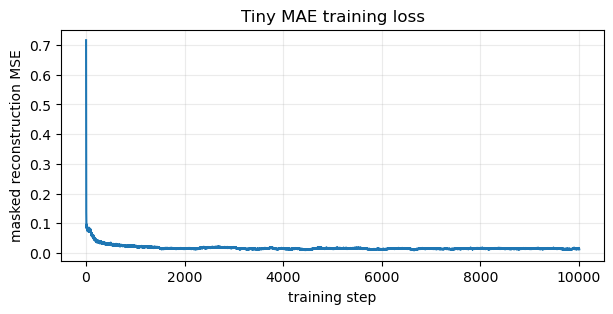

In [7]:
plt.figure(figsize=(7, 3))
plt.plot(loss_history)
plt.xlabel("training step")
plt.ylabel("masked reconstruction MSE")
plt.title("Tiny MAE training loss")
plt.grid(alpha=0.25)
plt.show()

## Inspect validation reconstructions

The reconstruction column preserves visible patches from the input and fills only masked patches with model predictions.

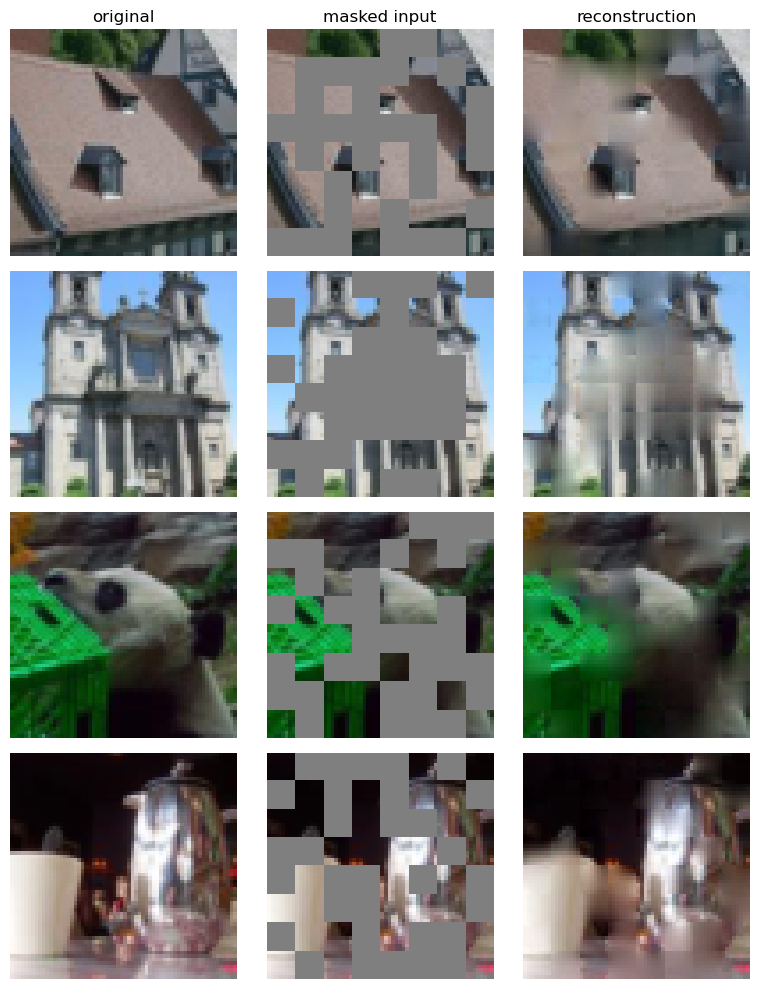

In [8]:
targets = patchify(eval_images[:8], config.patch_size)
display_predictions = final_predictions[:8]
display_mask = eval_mask[:8]
masked_patches = targets.clone()
masked_patches[display_mask] = 0.5
completed_patches = torch.where(display_mask.unsqueeze(-1), display_predictions, targets)

masked_images = unpatchify(masked_patches, config.patch_size, config.image_size).clamp(0, 1)
completed_images = unpatchify(completed_patches, config.patch_size, config.image_size).clamp(0, 1)

fig, axes = plt.subplots(4, 3, figsize=(8, 10))
for row in range(4):
    for column, batch in enumerate((eval_images, masked_images, completed_images)):
        axes[row, column].imshow(batch[row].permute(1, 2, 0))
        axes[row, column].axis("off")
    axes[row, 0].set_ylabel(class_names[eval_labels[row]][:24])
for column, title in enumerate(("original", "masked input", "reconstruction")):
    axes[0, column].set_title(title)
plt.tight_layout()
plt.show()

## Next steps

- Select a balanced subset of target, neighboring, and distractor ImageNet classes.
- Increase image resolution and model size after this smoke run is stable.
- Replace ordinary `AdamW.step()` with an explicit functional optimizer only when beginning metagradient work.